In [ ]:
import pandas as pd
from getpass import getpass
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from scipy import stats

engine = create_engine(URL.create(
    "postgresql+psycopg2", username="postgres",
    password=getpass("Postgres password: "),
    host="localhost", port=5432, database="olist_dw"))

sql = """
SELECT r.order_id, r.review_score, o.is_late
FROM (SELECT DISTINCT ON (order_id) order_id, review_score
      FROM dw.fact_reviews
      ORDER BY order_id, review_key DESC) r
JOIN (SELECT order_id, BOOL_OR(is_late) AS is_late
      FROM dw.fact_order_items
      WHERE delivery_days IS NOT NULL
      GROUP BY order_id) o USING (order_id)
"""
df = pd.read_sql(sql, engine)
df["is_late"] = df["is_late"].astype(bool)

late = df.loc[df["is_late"], "review_score"]
ontime = df.loc[~df["is_late"], "review_score"]

print(df.groupby("is_late")["review_score"].agg(["count", "mean", "median"]))

u, p = stats.mannwhitneyu(late, ontime, alternative="two-sided")
print(f"\nU = {u:,.0f}, p-value = {p:.3g}")
print(f"P(a random late order out-scores a random on-time one) = "
      f"{u / (len(late) * len(ontime)):.3f}")

In [4]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

sql = """
SELECT DATE_TRUNC('month', d.full_date)::date AS month, SUM(f.price) AS revenue
FROM dw.fact_order_items f
JOIN dw.dim_date d ON d.date_key = f.purchase_date_key
WHERE f.order_status = 'delivered'
  AND f.purchase_date_key BETWEEN 20170101 AND 20180831
GROUP BY 1 ORDER BY 1
"""
s = pd.read_sql(sql, engine, index_col="month")["revenue"].astype(float)
s.index = pd.to_datetime(s.index)
s = s.asfreq("MS")

train, test = s[:-3], s[-3:]

naive_fc = pd.Series(train.iloc[-1], index=test.index)
ets_fc = ExponentialSmoothing(train, trend="add", damped_trend=True).fit().forecast(3)
arima_fc = ARIMA(train, order=(1, 1, 1)).fit().forecast(3)

def mape(actual, fc):
    return (abs(actual - fc) / actual).mean() * 100

print(f"Naive (repeat last month): {mape(test, naive_fc):.1f}% error")
print(f"Damped exponential smoothing: {mape(test, ets_fc):.1f}% error")
print(f"ARIMA(1,1,1): {mape(test, arima_fc):.1f}% error")

Naive (repeat last month): 14.5% error
Damped exponential smoothing: 29.8% error
ARIMA(1,1,1): 13.5% error


revenue         mean  mean_ci_lower  mean_ci_upper
month                                             
2018-09-01  865641.0       642652.0      1088629.0
2018-10-01  842502.0       565125.0      1119879.0
2018-11-01  862285.0       511600.0      1212970.0


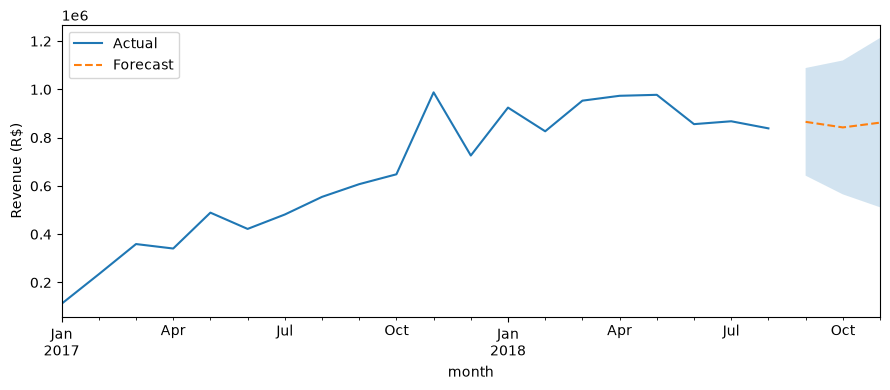

In [5]:
import matplotlib.pyplot as plt

final = ARIMA(s, order=(1, 1, 1)).fit()
fc = final.get_forecast(3)
out = fc.summary_frame(alpha=0.05)[["mean", "mean_ci_lower", "mean_ci_upper"]]
out.index.name = "month"
print(out.round(0))

ax = s.plot(label="Actual", figsize=(9, 4))
out["mean"].plot(ax=ax, label="Forecast", linestyle="--")
ax.fill_between(out.index, out["mean_ci_lower"], out["mean_ci_upper"], alpha=0.2)
ax.set_ylabel("Revenue (R$)")
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Projects\olist-analytics\results\revenue_forecast.png", dpi=150)
out.round(0).to_csv(r"C:\Projects\olist-analytics\results\revenue_forecast.csv")